In [1]:
# ─── STEP 0A: Install supporting libraries ─────────────────────────────
!pip install -q maxcorr networkx matplotlib scikit-learn

# ─── STEP 0B: Remove broken lingam (if any) ───────────────────────────
!pip uninstall -y lingam

# ─── STEP 0C: Clone official lingam repo and install from source ─────
!git clone https://github.com/cdt15/lingam.git
%cd lingam
!pip install -e .

# ─── STEP 0D: Go back to notebook root ────────────────────────────────
%cd ..

# ─── STEP 0E: Confirm versions and test imports ───────────────────────
import importlib, pkg_resources, sys, platform

# Check core packages
pkgs = ["lingam", "maxcorr", "networkx", "matplotlib", "scikit-learn"]
for pkg in pkgs:
    try:
        m = importlib.import_module(pkg)
        ver = getattr(m, "__version__", pkg_resources.get_distribution(pkg).version)
    except Exception as e:
        ver = f"[error: {e}]"
    print(f"{pkg:15s}: {ver}")

# Check Python info
print(f"Python           : {sys.version.split()[0]} on {platform.system()}-{platform.machine()}")

# Test that DirectLiNGAM is working
from lingam import DirectLiNGAM
print("\n✅ SUCCESS: DirectLiNGAM is importable.")



[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
Found existing installation: lingam 1.10.0
Uninstalling lingam-1.10.0:
  Successfully uninstalled lingam-1.10.0
fatal: destination path 'lingam' already exists and is not an empty directory.
/Users/yasaman/Desktop/HGRLiNGAM/lingam
Obtaining file:///Users/yasaman/Desktop/HGRLiNGAM/lingam
  Preparing metadata (setup.py) ... done
  DEPRECATION: Legacy editable install of lingam==1.10.0 from file:///Users/yasaman/Desktop/HGRLiNGAM/lingam (setup.py develop) is deprecated. pip 25.0 will enforce this behaviour change. A possible replacement is to add a pyproject.toml or enable --use-pep517, and use setuptools >= 64. If the resulting installation is not behaving as expected, try using --config-settings editable_mode=compat. Please consult the setuptools documentation for more information. Discussion can be found at https://github.com/pypa/pip/issues/11457
  Running setup.py develop 

In [ ]:
# ─── STEP L‑1: imports and DAG plotting helper ───────────────────────────────

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

from lingam import DirectLiNGAM
from maxcorr import indicator

import warnings
warnings.filterwarnings("ignore")  # Keeps output tidy

# ─── DAG visualisation utility ──────────────────────────────────────────────

def plot_dag(adj_matrix, labels=None, title="Estimated DAG", layout="shell",
             edge_labels=True, ax=None):
    G = nx.DiGraph()
    n = adj_matrix.shape[0]
    if labels is None:
        labels = [f"x{i}" for i in range(n)]
    G.add_nodes_from(labels)

    edges = []
    weights = {}
    for i in range(n):
        for j in range(n):
            if adj_matrix[i, j] != 0:
                G.add_edge(labels[j], labels[i])  # j → i
                weights[(labels[j], labels[i])] = round(adj_matrix[i, j], 2)

    if layout == "spring":
        pos = nx.spring_layout(G, seed=42)
    elif layout == "circular":
        pos = nx.circular_layout(G)
    else:
        pos = nx.shell_layout(G)

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))

        nx.draw(G, pos, with_labels=True, arrows=True,
                node_size=800, node_color="skyblue", edge_color="black",
                font_size=10, ax=ax)
    if edge_labels:
        nx.draw_networkx_edge_labels(G, pos, edge_labels=weights, font_size=8, ax=ax)

    ax.set_title(title)
    ax.axis("off")




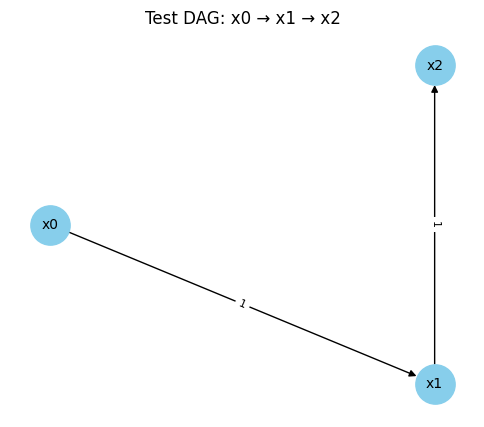

In [111]:
# ─── STEP 1 TEST: dummy DAG for visual check ─────────────────────────────

# Dummy 3-variable DAG: x0 → x1 → x2
A_test = np.array([
    [0, 0, 0],
    [1, 0, 0],
    [0, 1, 0]
])

plot_dag(A_test, title="Test DAG: x0 → x1 → x2")


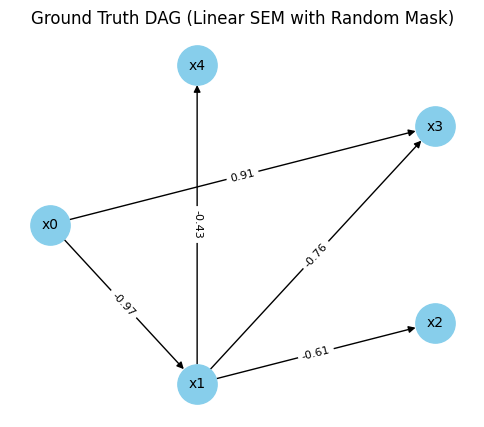

In [112]:
# ─── STEP L‑2 (Your original logic, now seed-sensitive structure) ───────────

def simulate_linear_lingam(n_samples=1000, n_vars=5, seed=42, edge_prob=0.6, min_weight=0.3):
    np.random.seed(seed)
    
    # Step 1: build strictly lower-triangular candidate matrix
    B = np.zeros((n_vars, n_vars))
    for i in range(n_vars):
        for j in range(i):
            if np.random.rand() < edge_prob:
                # Sample from a uniform range away from zero
                weight = np.random.uniform(min_weight, 1.0)
                weight *= np.random.choice([-1, 1])  # random sign
                B[i, j] = weight

    # Step 2: non-Gaussian noise (Laplace)
    E = np.random.laplace(loc=0, scale=1.0, size=(n_samples, n_vars))

    # Step 3: Solve linear SEM
    I = np.eye(n_vars)
    X = E @ np.linalg.inv(I - B.T)

    return X, B

# Generate and visualize
X_L, B_true_L = simulate_linear_lingam(n_samples=1000, n_vars=5, seed=42, edge_prob=0.6)
plot_dag(B_true_L, title="Ground Truth DAG (Linear SEM with Random Mask)")


Estimated causal order: [0, 1, 2, 3, 4]


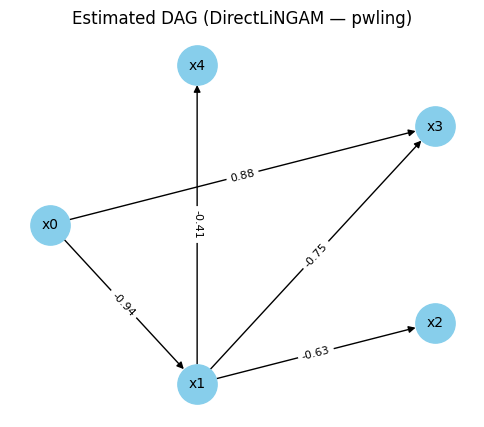

In [113]:
# ─── STEP L‑3: Baseline DirectLiNGAM (pwling) ─────────────────────────────

# Fit the model on linear data
model_pwling = DirectLiNGAM(measure="direct", random_state=0)
model_pwling.fit(X_L)

# Extract estimated adjacency
B_est_pwling = model_pwling.adjacency_matrix_

# Plot estimated DAG
plot_dag(B_est_pwling, title="Estimated DAG (DirectLiNGAM — pwling)")

# Show causal order for reference
print("Estimated causal order:", model_pwling.causal_order_)


In [114]:
from lingam.direct_lingam import DirectLiNGAM as BaseDirectLiNGAM
from maxcorr import indicator

class HGRDirectLiNGAM(BaseDirectLiNGAM):
    def __init__(self, semantics='hgr', algorithm='dk', backend='numpy', kernel_a=5, kernel_b=5):
        super().__init__(measure='hgr', **kwargs)
        self._hgr = indicator(semantics=semantics, algorithm=algorithm, backend=backend, kernel_a= kernel_a, kernel_b= kernel_b)

    def _search_causal_order(self, X, U):
        from sklearn.linear_model import LinearRegression
        print("⏰ HGR search step – remaining:", U)
        min_dep, exo = np.inf, None
        for i in U:
            x_i = X[:, i]
            dep = 0.0
            for j in U:
                if i == j:
                    continue
                # regress x_j on x_i, compute residual r_{j←i}
                lr = LinearRegression().fit(x_i.reshape(-1, 1), X[:, j])
                r_ji = X[:, j] - lr.predict(x_i.reshape(-1, 1))
                # HGR dependence between x_i and residual
                dep += self._hgr.compute(x_i, r_ji) ** 2
            if dep < min_dep:
                min_dep, exo = dep, i
        return exo        # ***scalar index, not a list***


In [115]:
# ─── STEP L‑5b: Run custom HGR-LiNGAM ─────────────────────────────────────

model_hgr = HGRDirectLiNGAM(random_state=0)
model_hgr.fit(X_L)

B_est_hgr = model_hgr.adjacency_matrix_

plot_dag(B_est_hgr, title="Estimated DAG (HGR-DirectLiNGAM)")
print("Estimated causal order:", model_hgr.causal_order_)


TypeError: __init__() got an unexpected keyword argument 'random_state'

In [116]:
# ── Inline DK‑HGR LiNGAM – fixed for maxcorr ≥ 0.1.2 ────────────────────
from lingam.direct_lingam import DirectLiNGAM
from maxcorr import indicator
from sklearn.linear_model import LinearRegression
import numpy as np

class InlineDKHGRLiNGAM(DirectLiNGAM):
    def __init__(self, *, kernel_a, kernel_b, **dl_kw):
        super().__init__(measure="hgr-inline", **dl_kw)
        self.kernel_a, self.kernel_b = kernel_a, kernel_b

    # --- helper ----------------------------------------------------------
    def _dk_hgr(self, x, y, want_maps=False):
        """Compute ρ_HGR(x,y); optionally return the copula projections."""
        ind = indicator(semantics="hgr",
                        algorithm="dk",
                        backend="numpy",
                        kernel_a=self.kernel_a,
                        kernel_b=self.kernel_b)
        res = ind(x, y)                                    # ① run DK‑HGR
        rho = res.value                                    #   scalar corr  :contentReference[oaicite:0]{index=0}
        if want_maps:                                      # ② grab f(x), g(y)
            f_x = ind.f(x)     # uses last_result inside   :contentReference[oaicite:1]{index=1}
            g_y = ind.g(y)
            return rho, f_x, g_y
        return rho

    # --- causal‑order search (unchanged apart from new helper) -----------
    def _search_causal_order(self, X, U):
        print("⏰ HGR search step – remaining:", U)
        best_dep, exo = np.inf, None
        for i in U:                                # candidate parent
            dep = 0.0
            for j in U:
                if i == j:
                    continue
                ρ, f_i, g_j = self._dk_hgr(X[:, i], X[:, j], want_maps=True)

                # linear fit in transformed space
                beta = np.dot(f_i, g_j) / np.dot(f_i, f_i)
                r = g_j - beta * f_i

                dep += self._dk_hgr(f_i, r) ** 2   # independence score
            if dep < best_dep:
                best_dep, exo = dep, i
        return exo


⏰ HGR search step – remaining: [0 1 2 3 4]
⏰ HGR search step – remaining: [1 2 3 4]
⏰ HGR search step – remaining: [2 3 4]
⏰ HGR search step – remaining: [3 4]
⏰ HGR search step – remaining: [3]
Causal order: [0, 1, 2, 4, 3]


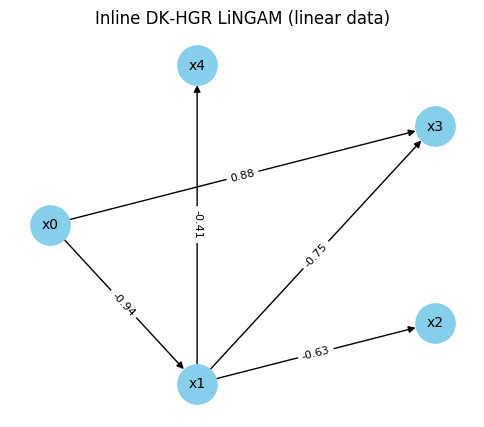

In [117]:
model_inline = InlineDKHGRLiNGAM(kernel_a=5, kernel_b=1, random_state=0)
model_inline.fit(X_L)

plot_dag(model_inline.adjacency_matrix_,
         title="Inline DK‑HGR LiNGAM (linear data)")
print("Causal order:", model_inline.causal_order_)


In [118]:
# ─── STEP L‑8: Compute Structural Hamming Distance ───────────────────────
from cdt.metrics import SHD
import numpy as np

def compute_shd(B_true, B_est, double_for_anticausal=True):
    """
    Computes SHD between true adjacency B_true and estimated B_est.
    Assumes 1 for directed edges; nonzero weights are treated as edges.
    """
    target = (B_true != 0).astype(int)
    pred   = (B_est   != 0).astype(int)
    return SHD(target, pred, double_for_anticausal=double_for_anticausal)

# Example usage right after fitting each model:

print("Plain LiNGAM SHD:", compute_shd(B_true_L, model_pwling.adjacency_matrix_))
print("HGR‑LiNGAM SHD:", compute_shd(B_true_L, B_est_hgr))
print("Inline DK‑HGR‑LiNGAM SHD:", compute_shd(B_true_L, model_inline.adjacency_matrix_))


Plain LiNGAM SHD: 0
HGR‑LiNGAM SHD: 0
Inline DK‑HGR‑LiNGAM SHD: 0


In [119]:
def apply_polynomial_nonlinearity(s, mode):
    if mode == 0:
        return s + 0.1 * s**2                  # quadratic bias
    elif mode == 1:
        return s**2 + 0.05 * s**3              # strong nonlinearity
    elif mode == 2:
        return 0.5 * s + 0.2 * s**3 + 0.05*s**4  # cubic + quartic
    elif mode == 3:
        return s


In [120]:
def generate_nonlinear_data(n=1000, p=5, min_weight=0.5, seed=0, mode = None):
    """
    Nonlinear SEM generator using polynomial nonlinearities.
    Each node uses one of 3 fixed polynomial-based mappings.
    """
    rng = np.random.default_rng(seed)
    B = np.zeros((p, p))

    # Random upper-triangular DAG
    for i in range(p):
        for j in range(i + 1, p):
            if rng.random() < 0.5:
                weight = rng.uniform(min_weight, 1.0) * rng.choice([-1, 1])
                B[j, i] = weight

    X = np.zeros((n, p))
    for j in range(p):
        parents = np.where(B[j, :] != 0)[0]
        if len(parents) == 0:
            X[:, j] = rng.standard_t(df=3, size=n)
        else:
            parent_vals = X[:, parents]
            weights = B[j, parents]
            s = parent_vals @ weights

              # pick one of 3 polynomial forms
            nonlin = apply_polynomial_nonlinearity(s, mode)

            X[:, j] = nonlin + 0.5 * rng.standard_normal(n)

    return X, B


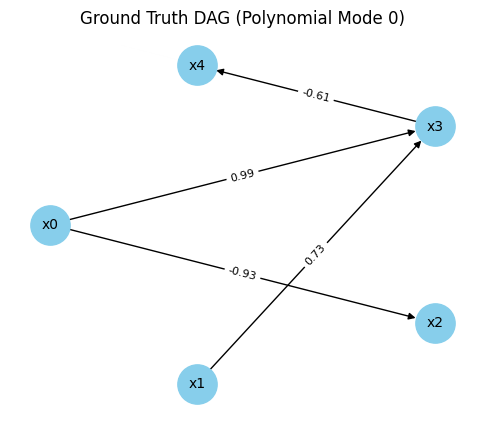

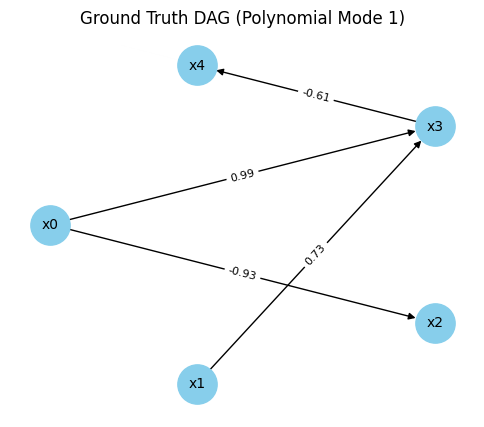

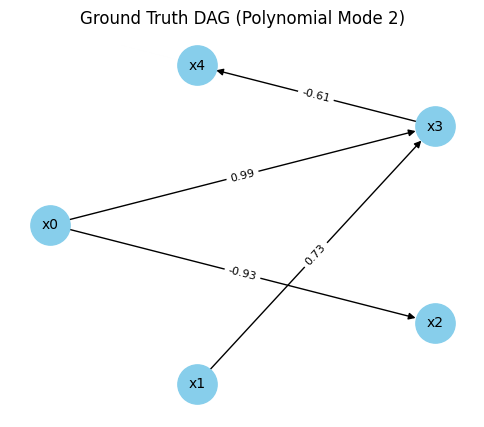

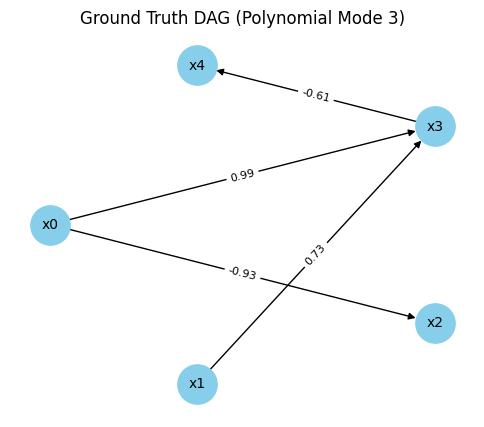

In [121]:
# Generate & plot ground-truth DAGs for modes 0, 1, 2 (polynomial types)
for mode in [0, 1, 2, 3]:
    X_nl, B_nl = generate_nonlinear_data(n=1000, p=5, seed=42, mode=mode)
    plot_dag(B_nl, title=f"Ground Truth DAG (Polynomial Mode {mode})")


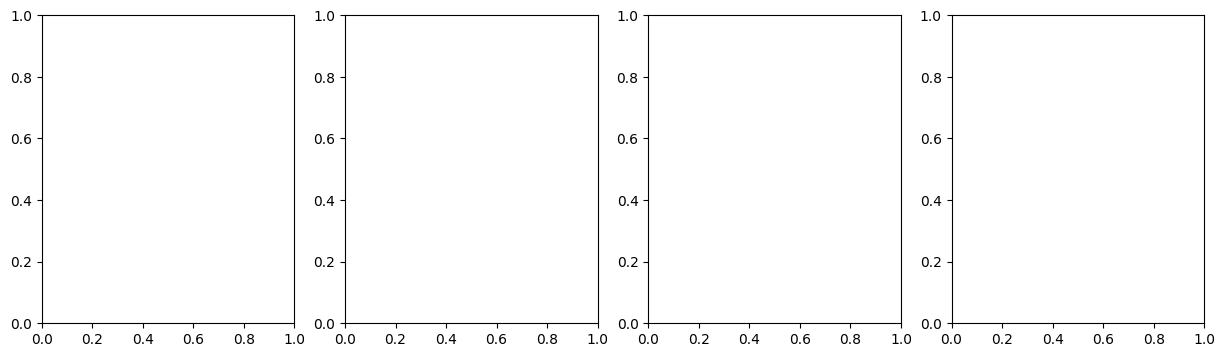

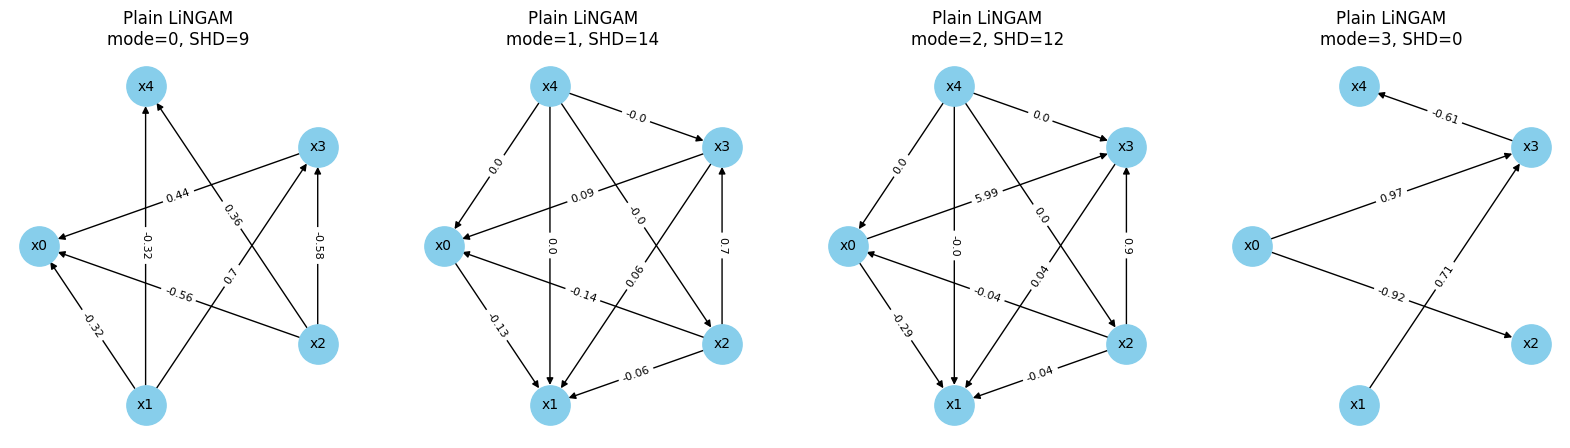

In [123]:
import matplotlib.pyplot as plt
import networkx as nx

# Ensure SHD function is defined
from cdt.metrics import SHD

def compute_shd(B_true, B_est):
    target = (B_true != 0).astype(int)
    pred   = (B_est   != 0).astype(int)
    return SHD(target, pred)

# ── Run plain LiNGAM for modes 0, 1, 2 and plot results ──
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
shd_scores = []

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
shd_scores = []

for idx, mode in enumerate([0, 1, 2, 3]):
    X_nl, B_true_nl = generate_nonlinear_data(n=1000, p=5, seed=42, mode=mode)

    model = DirectLiNGAM(measure="pwling", random_state=0)
    model.fit(X_nl)
    B_est = model.adjacency_matrix_

    shd = compute_shd(B_true_nl, B_est)
    shd_scores.append(shd)

    plot_dag(B_est, title=f"Plain LiNGAM\nmode={mode}, SHD={shd}", ax=axes[idx])


